# Cross-Lingual Transfer in Indic Financial NLP — Result Graphs

This notebook builds the figures for the presentation. It does not run any
training or translation itself — it takes numbers that were already measured
in this project (fine-tuning two encoders, mBERT and IndicBERT-v2, on Hindi/
Bengali/Telugu financial text and testing them on the other languages) and
turns them into charts.

**The core question the project asks:** if you only have labelled financial
text in one Indian language, how much accuracy do you lose when you apply the
model to a *different* Indian language you never trained it on? That loss is
called the "transfer gap" throughout this notebook — it's simply
(accuracy in the model's own training language) minus (accuracy in the new
language), measured on the same set of items so it's a fair comparison.

Two downstream tasks are covered:
- **Task 2** — sustainability sentence classification (binary: sustainable /
  unsustainable)
- **Task 3** — ESG news headline classification (10 classes, and much harder —
  scores are low across the board)

All numbers below are copied from `reports/source_comparison.md` and
`reports/encoder_comparison.md` (task T-408 / T-504), each averaged over 3
random seeds. This notebook is self-contained — no repo files need to be
uploaded to Colab to run it.


In [1]:
!pip -q install matplotlib pandas numpy seaborn --upgrade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Consistent colors used across every figure in this notebook.
COLOR_INDICBERT = "#4C72B0"   # blue
COLOR_MBERT     = "#DD8452"   # orange
COLOR_TASK2     = "#55A868"   # green
COLOR_TASK3     = "#C44E52"   # red


## 1. The data

Transcribed directly from the project's own result tables
(`reports/source_comparison.md`, T-408). Each row is one "train on language A,
test on language B" experiment, for each of the two encoders.


In [2]:
# Task 2 (sustainability classification): source language -> target language,
# the gap (source accuracy - target accuracy), and the raw source/target scores.
task2_rows = [
    # encoder,        source, target, gap,    source_f1, target_f1
    ("indicbert-v2", "ben", "hin", 0.2631, 0.9558, 0.6927),
    ("indicbert-v2", "ben", "mal", 0.3673, 0.9558, 0.5885),
    ("indicbert-v2", "ben", "tel", 0.4040, 0.9558, 0.5518),
    ("indicbert-v2", "hin", "ben", 0.4477, 0.9535, 0.5058),
    ("indicbert-v2", "hin", "mal", 0.3868, 0.9535, 0.5667),
    ("indicbert-v2", "hin", "tel", 0.4526, 0.9535, 0.5009),
    ("indicbert-v2", "tel", "ben", 0.3234, 0.9573, 0.6338),
    ("indicbert-v2", "tel", "hin", 0.3610, 0.9573, 0.5962),
    ("indicbert-v2", "tel", "mal", 0.4167, 0.9573, 0.5405),
    ("mbert-base",   "ben", "hin", 0.1052, 0.9752, 0.8699),
    ("mbert-base",   "ben", "mal", 0.1789, 0.9752, 0.7963),
    ("mbert-base",   "ben", "tel", 0.1762, 0.9752, 0.7990),
    ("mbert-base",   "hin", "ben", 0.1415, 0.9747, 0.8333),
    ("mbert-base",   "hin", "mal", 0.2090, 0.9747, 0.7657),
    ("mbert-base",   "hin", "tel", 0.2364, 0.9747, 0.7383),
    ("mbert-base",   "tel", "ben", 0.1960, 0.9710, 0.7750),
    ("mbert-base",   "tel", "hin", 0.1593, 0.9710, 0.8117),
    ("mbert-base",   "tel", "mal", 0.1671, 0.9710, 0.8039),
]
task2 = pd.DataFrame(task2_rows, columns=["encoder", "source", "target", "gap", "source_f1", "target_f1"])
task2["task"] = "task_2 (sustainability)"

# Task 3 (ESG headline classification, 10-way): same shape.
task3_rows = [
    ("indicbert-v2", "ben", "hin", 0.5230, 0.5899, 0.0669),
    ("indicbert-v2", "ben", "mal", 0.5149, 0.5899, 0.0750),
    ("indicbert-v2", "ben", "tel", 0.5042, 0.5899, 0.0858),
    ("indicbert-v2", "hin", "ben", 0.5096, 0.5958, 0.0862),
    ("indicbert-v2", "hin", "mal", 0.5035, 0.5958, 0.0923),
    ("indicbert-v2", "hin", "tel", 0.5141, 0.5958, 0.0817),
    ("indicbert-v2", "tel", "ben", 0.4777, 0.5851, 0.1075),
    ("indicbert-v2", "tel", "hin", 0.4778, 0.5851, 0.1073),
    ("indicbert-v2", "tel", "mal", 0.4560, 0.5851, 0.1291),
    ("mbert-base",   "ben", "hin", 0.4938, 0.8099, 0.3161),
    ("mbert-base",   "ben", "mal", 0.5379, 0.8099, 0.2719),
    ("mbert-base",   "ben", "tel", 0.5226, 0.8099, 0.2873),
    ("mbert-base",   "hin", "ben", 0.5155, 0.8052, 0.2897),
    ("mbert-base",   "hin", "mal", 0.5611, 0.8052, 0.2441),
    ("mbert-base",   "hin", "tel", 0.5160, 0.8052, 0.2892),
    ("mbert-base",   "tel", "ben", 0.5240, 0.7839, 0.2599),
    ("mbert-base",   "tel", "hin", 0.4888, 0.7839, 0.2950),
    ("mbert-base",   "tel", "mal", 0.5284, 0.7839, 0.2555),
]
task3 = pd.DataFrame(task3_rows, columns=["encoder", "source", "target", "gap", "source_f1", "target_f1"])
task3["task"] = "task_3 (ESG headlines)"

transfer = pd.concat([task2, task3], ignore_index=True)

# Translationese comparison: for a fixed language, does it matter whether the
# training text is the real native split or a machine-translated one from a
# different source language? From encoder_comparison.md (T-504), Hindi arm.
translationese_rows = [
    # task,                     encoder,        arm,        origin,  f1
    ("task_2 (sustainability)", "indicbert-v2", "Bengali->Hindi (MT)",  "mt",     0.8848),
    ("task_2 (sustainability)", "indicbert-v2", "Hindi (native)",       "native", 0.9536),
    ("task_2 (sustainability)", "indicbert-v2", "Telugu->Hindi (MT)",   "mt",     0.8962),
    ("task_2 (sustainability)", "mbert-base",   "Bengali->Hindi (MT)",  "mt",     0.9443),
    ("task_2 (sustainability)", "mbert-base",   "Hindi (native)",       "native", 0.9772),
    ("task_2 (sustainability)", "mbert-base",   "Telugu->Hindi (MT)",   "mt",     0.9531),
    ("task_3 (ESG headlines)",  "indicbert-v2", "Bengali->Hindi (MT)",  "mt",     0.3324),
    ("task_3 (ESG headlines)",  "indicbert-v2", "Hindi (native)",       "native", 0.5941),
    ("task_3 (ESG headlines)",  "indicbert-v2", "Telugu->Hindi (MT)",   "mt",     0.3275),
    ("task_3 (ESG headlines)",  "mbert-base",   "Bengali->Hindi (MT)",  "mt",     0.6051),
    ("task_3 (ESG headlines)",  "mbert-base",   "Hindi (native)",       "native", 0.7943),
    ("task_3 (ESG headlines)",  "mbert-base",   "Telugu->Hindi (MT)",   "mt",     0.6144),
]
translationese = pd.DataFrame(translationese_rows, columns=["task", "encoder", "arm", "origin", "f1"])

transfer.head()


,encoder,source,target,gap,source_f1,target_f1,task
0,indicbert-v2,ben,hin,0.2631,0.9558,0.6927,task_2 (sustainability)
1,indicbert-v2,ben,mal,0.3673,0.9558,0.5885,task_2 (sustainability)
2,indicbert-v2,ben,tel,0.4040,0.9558,0.5518,task_2 (sustainability)
3,indicbert-v2,hin,ben,0.4477,0.9535,0.5058,task_2 (sustainability)
4,indicbert-v2,hin,mal,0.3868,0.9535,0.5667,task_2 (sustainability)


## 2. Figure 1 — Transfer gap heatmap: which language pairs transfer worst?

Each tile is one "trained on the row language, tested on the column language"
experiment. **Darker = bigger drop in accuracy** when the model sees a
language it wasn't trained on. Reading this heatmap answers the plainest
version of the project's question at a glance: pick any two languages, and
see how much accuracy you'd lose going from one to the other.

Two encoders are shown side by side so you can also see that the *pattern* of
which pairs are hard stays similar even though mBERT's gaps are consistently
smaller than IndicBERT-v2's (mBERT is simply a stronger multilingual model
here).


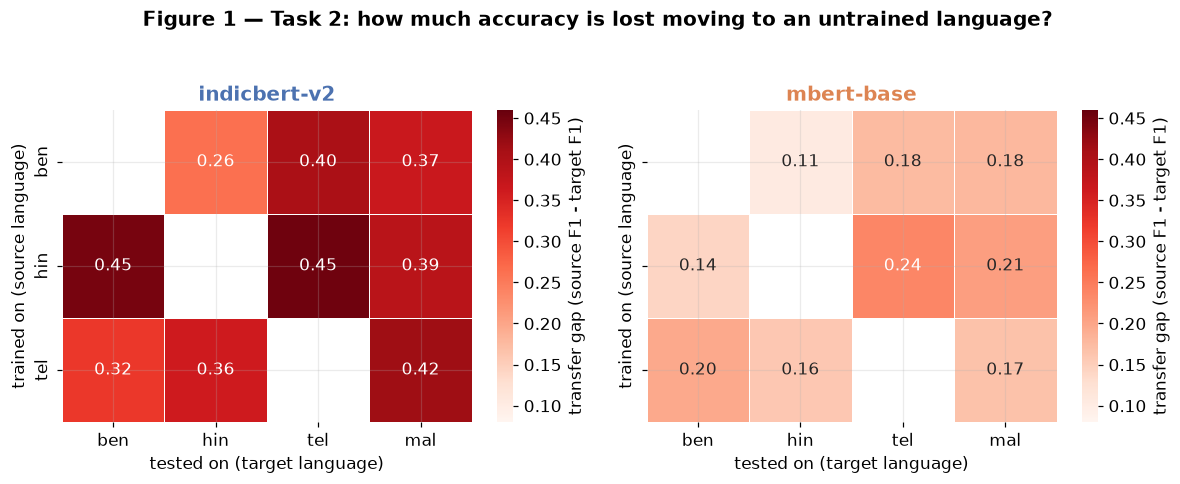

In [3]:
def gap_matrix(df, encoder, task, langs=("ben", "hin", "tel", "mal")):
    sub = df[(df.encoder == encoder) & (df.task == task)]
    mat = pd.DataFrame(index=[l for l in langs if l != "mal"], columns=langs, dtype=float)
    for _, r in sub.iterrows():
        mat.loc[r.source, r.target] = r.gap
    return mat

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
task_name = "task_2 (sustainability)"
for ax, enc, color in zip(axes, ["indicbert-v2", "mbert-base"], [COLOR_INDICBERT, COLOR_MBERT]):
    mat = gap_matrix(transfer, enc, task_name)
    sns.heatmap(
        mat, annot=True, fmt=".2f", cmap="Reds", vmin=0.08, vmax=0.46,
        cbar_kws={"label": "transfer gap (source F1 - target F1)"}, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(enc, fontweight="bold", color=color)
    ax.set_xlabel("tested on (target language)")
    ax.set_ylabel("trained on (source language)")

fig.suptitle("Figure 1 — Task 2: how much accuracy is lost moving to an untrained language?",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("fig1_transfer_gap_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Figure 2 — Does the *target* language drive the cost, or the pairing?

This groups every experiment by whether the target language is Indo-Aryan
(Hindi, Bengali) or Dravidian (Telugu, Malayalam), averaged over which source
language was used. If crossing into the Dravidian family is inherently harder
than crossing into Indo-Aryan — regardless of which language you start from —
the Dravidian bars should sit clearly above the Indo-Aryan bars.


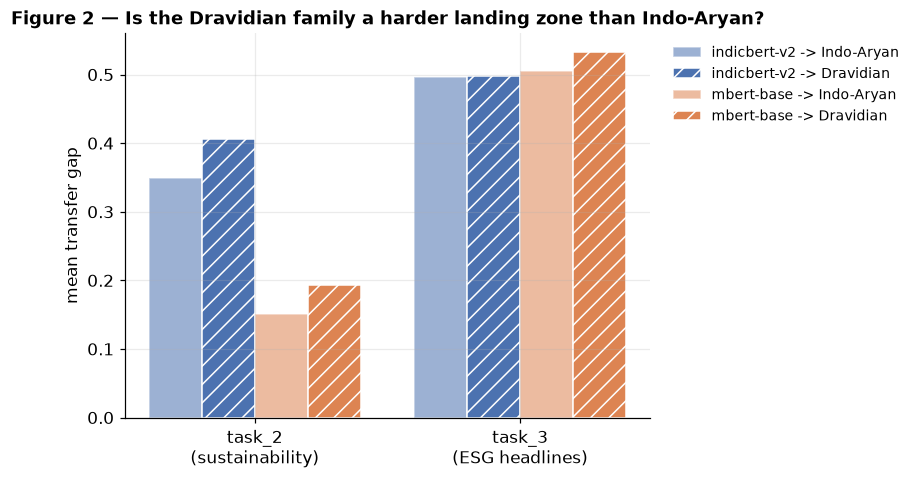

In [4]:
family = {"ben": "Indo-Aryan", "hin": "Indo-Aryan", "tel": "Dravidian", "mal": "Dravidian"}
transfer["target_family"] = transfer["target"].map(family)

fam = (transfer.groupby(["task", "encoder", "target_family"])["gap"]
       .mean().reset_index())

fig, ax = plt.subplots(figsize=(8, 4.5))
tasks = fam["task"].unique()
encoders = ["indicbert-v2", "mbert-base"]
families = ["Indo-Aryan", "Dravidian"]
x = np.arange(len(tasks))
width = 0.2
colors = {"indicbert-v2": COLOR_INDICBERT, "mbert-base": COLOR_MBERT}
hatches = {"Indo-Aryan": "", "Dravidian": "//"}

offsets = np.linspace(-1.5, 1.5, 4) * width
i = 0
for enc in encoders:
    for f in families:
        vals = [fam[(fam.task == t) & (fam.encoder == enc) & (fam.target_family == f)]["gap"].values[0]
                for t in tasks]
        ax.bar(x + offsets[i], vals, width, label=f"{enc} -> {f}",
               color=colors[enc], hatch=hatches[f], edgecolor="white",
               alpha=0.55 if f == "Indo-Aryan" else 1.0)
        i += 1

ax.set_xticks(x)
ax.set_xticklabels([t.replace(" (", "\n(") for t in tasks])
ax.set_ylabel("mean transfer gap")
ax.set_title("Figure 2 — Is the Dravidian family a harder landing zone than Indo-Aryan?",
             fontsize=12, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig("fig2_target_family_cost.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Figure 3 — Real sentences vs. machine-translated sentences: does it matter what you train on?

For Hindi, three versions of "the same task" exist: the real, human-written
Hindi data, a machine-translated-from-Bengali version, and a
machine-translated-from-Telugu version — same labels, same language, only the
origin of the text differs. Training a model on the machine-translated
version and comparing it to training on the real thing isolates one specific
question: **how much of the accuracy loss we saw above is actually a
translation-quality problem, rather than a genuine cross-language transfer
problem?**


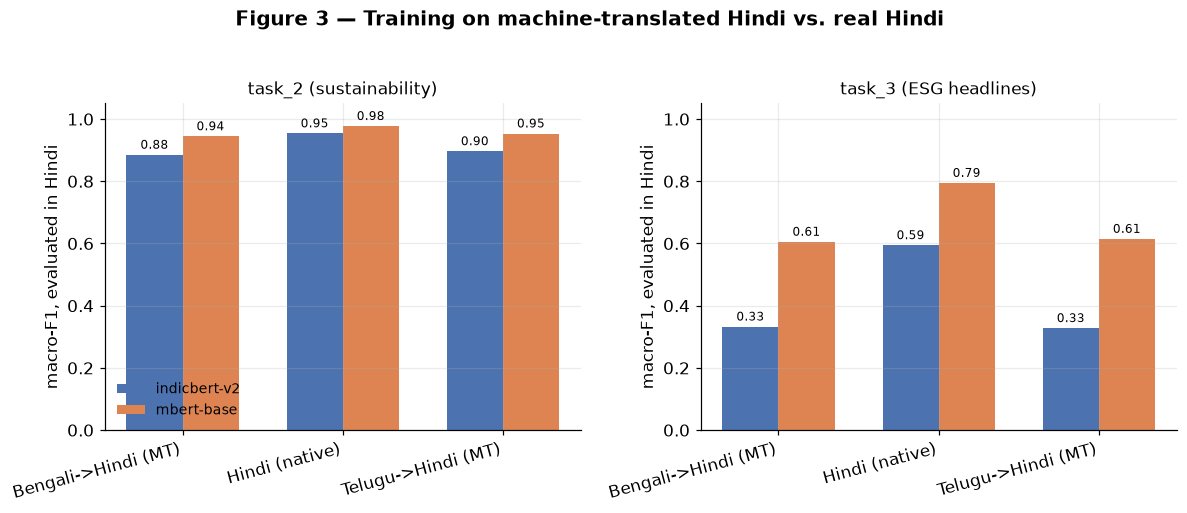

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

for ax, task_name in zip(axes, translationese["task"].unique()):
    sub = translationese[translationese.task == task_name]
    arms = ["Bengali->Hindi (MT)", "Hindi (native)", "Telugu->Hindi (MT)"]
    x = np.arange(len(arms))
    width = 0.35
    for j, (enc, color) in enumerate(zip(["indicbert-v2", "mbert-base"], [COLOR_INDICBERT, COLOR_MBERT])):
        vals = [sub[(sub.arm == a) & (sub.encoder == enc)]["f1"].values[0] for a in arms]
        bars = ax.bar(x + (j - 0.5) * width, vals, width, label=enc, color=color)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(arms, rotation=15, ha="right")
    ax.set_ylabel("macro-F1, evaluated in Hindi")
    ax.set_title(task_name, fontsize=11)
    ax.set_ylim(0, 1.05)

axes[0].legend(loc="lower left", fontsize=9, frameon=False)
fig.suptitle("Figure 3 — Training on machine-translated Hindi vs. real Hindi",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("fig3_translationese.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Figure 4 — Which source language transfers best, on average?

Averaging each source language's gap across all the languages it was tested
on gives a per-language "how good a teacher is this language" ranking. Lower
is better — it means less accuracy was lost when moving away from it.


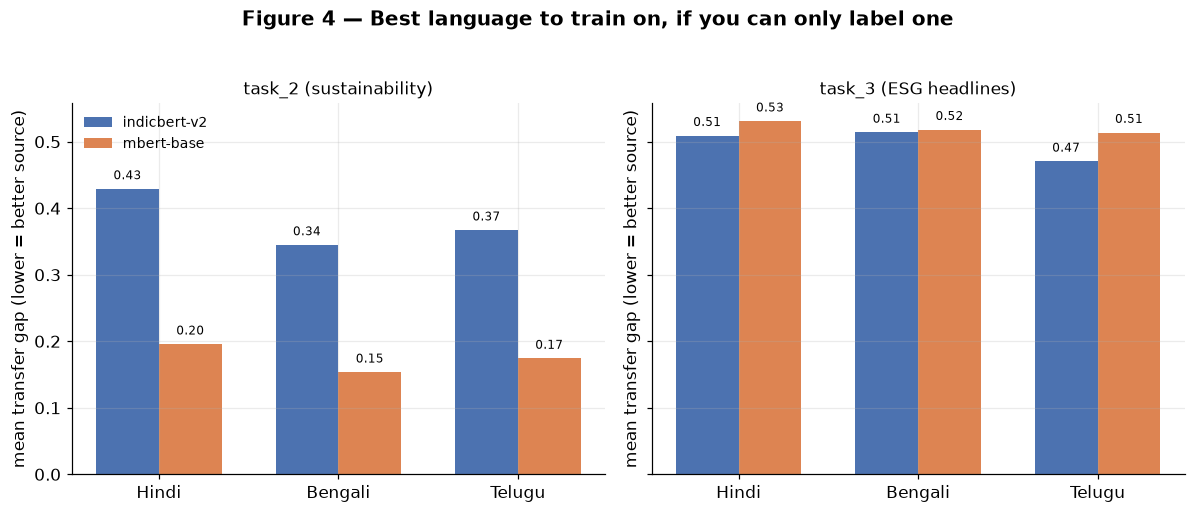

In [6]:
best_source = (transfer.groupby(["task", "encoder", "source"])["gap"]
               .mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
lang_names = {"ben": "Bengali", "hin": "Hindi", "tel": "Telugu"}

for ax, task_name in zip(axes, best_source["task"].unique()):
    sub = best_source[best_source.task == task_name]
    sources = ["hin", "ben", "tel"]
    x = np.arange(len(sources))
    width = 0.35
    for j, (enc, color) in enumerate(zip(["indicbert-v2", "mbert-base"], [COLOR_INDICBERT, COLOR_MBERT])):
        vals = [sub[(sub.source == s) & (sub.encoder == enc)]["gap"].values[0] for s in sources]
        bars = ax.bar(x + (j - 0.5) * width, vals, width, label=enc, color=color)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([lang_names[s] for s in sources])
    ax.set_ylabel("mean transfer gap (lower = better source)")
    ax.set_title(task_name, fontsize=11)

axes[0].legend(loc="upper left", fontsize=9, frameon=False)
fig.suptitle("Figure 4 — Best language to train on, if you can only label one",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("fig4_best_source_language.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Figure 5 — Is transfer symmetric? (Hindi -> Bengali vs. Bengali -> Hindi)

A natural assumption is that if training on A and testing on B loses X points,
training on B and testing on A should lose about the same. This figure checks
that directly for each language pair, for both encoders. Where the two bars
in a pair differ a lot, transfer is directional — going one way costs more
than going the other.


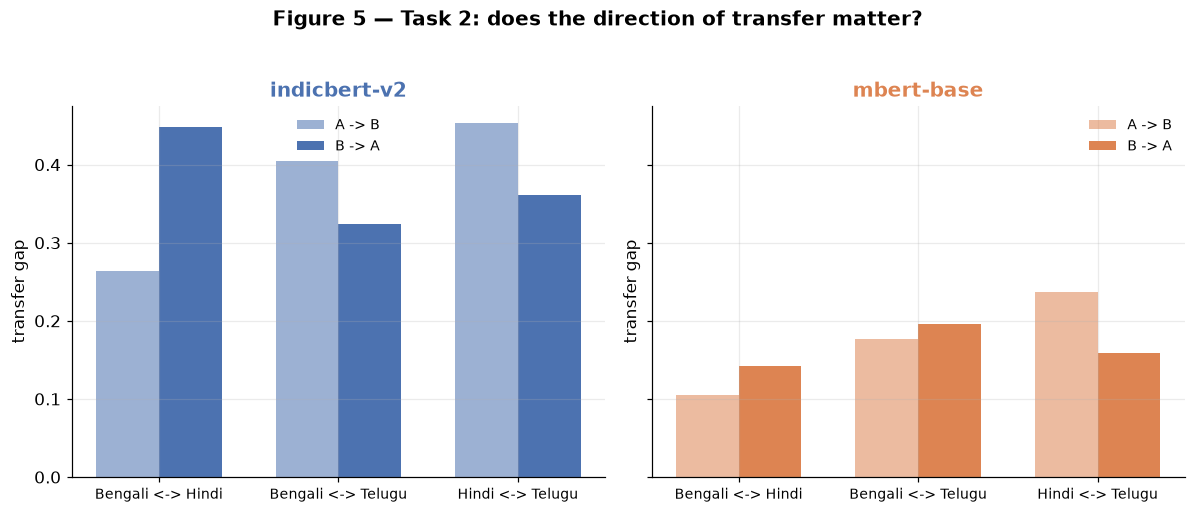

In [7]:
pairs = [("ben", "hin"), ("ben", "tel"), ("hin", "tel")]
task_name = "task_2 (sustainability)"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, enc, color in zip(axes, ["indicbert-v2", "mbert-base"], [COLOR_INDICBERT, COLOR_MBERT]):
    sub = transfer[(transfer.encoder == enc) & (transfer.task == task_name)]
    labels, forward, reverse = [], [], []
    for a, b in pairs:
        labels.append(f"{lang_names[a]} <-> {lang_names[b]}")
        forward.append(sub[(sub.source == a) & (sub.target == b)]["gap"].values[0])
        reverse.append(sub[(sub.source == b) & (sub.target == a)]["gap"].values[0])
    x = np.arange(len(pairs))
    width = 0.35
    ax.bar(x - width / 2, forward, width, label="A -> B", color=color, alpha=0.55)
    ax.bar(x + width / 2, reverse, width, label="B -> A", color=color, alpha=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("transfer gap")
    ax.set_title(enc, color=color, fontweight="bold")
    ax.legend(fontsize=9, frameon=False)

fig.suptitle("Figure 5 — Task 2: does the direction of transfer matter?",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("fig5_transfer_symmetry.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Takeaways for the slide notes

- **Figure 1** — every direction loses real accuracy (roughly 25–45 points of
  macro-F1 on the sustainability task), but IndicBERT-v2 loses noticeably more
  than mBERT everywhere, not just in some pairs.
- **Figure 2** — moving into a Dravidian-family language (Telugu, Malayalam)
  tends to cost a bit more than moving into another Indo-Aryan language, but
  the effect is small compared to the encoder choice — which model you use
  matters more than which two languages you're bridging.
- **Figure 3** — training on machine-translated text instead of the real
  native text costs several points of accuracy on top of the transfer gap
  itself, which means some of the difficulty seen elsewhere in this project is
  a translation-quality problem, not purely a "the model doesn't generalise
  across languages" problem.
- **Figure 4** — Hindi and Bengali are consistently better languages to train
  on than Telugu if you can only afford to label one language's data.
- **Figure 5** — transfer is not symmetric: going from Hindi into Bengali
  loses more accuracy than going from Bengali into Hindi, for both encoders.
  Which direction is "the hard one" is a property of the language pair, not
  of the model.
